### Astrostatistics lecture 10

100%|██████████| 999999/999999 [00:10<00:00, 92121.57it/s]


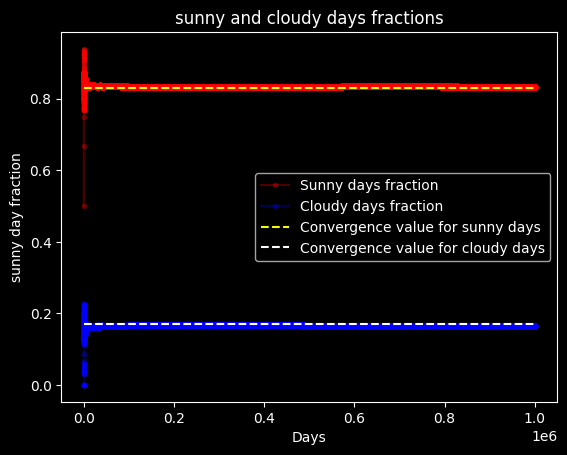

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.neighbors import KernelDensity
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

# First take a convention that sunny is 1 and cloudy is 0

def giuliacci(today):   # function that takes the weather of today and picks the weather tomorrow based on the probabilities
    if today == 1:  # if it's sunny we get 90% of sunny and 10% of cloudy
        tomorrow = np.random.choice([1, 0], p=[0.9, 0.1])
    else:           # if it's cloudy we get 50% of sunny and 50%
        tomorrow = np.random.choice([1, 0], p=[0.5, 0.5])
    return tomorrow

days = 10**6

Meteo = np.zeros(days, dtype=int)
sunny = 0
cloudy = 0
sunny_frac = []
cloudy_frac = []

for giorno in tqdm(range(1, days)):
    tomorrow = giuliacci(Meteo[giorno-1])
    Meteo[giorno] = tomorrow
    if tomorrow == 1:
        sunny += 1
    else:
        cloudy += 1
    sunny_frac.append(sunny / (giorno + 1))
    cloudy_frac.append(cloudy / (giorno + 1))

plt.plot(range(1, days), sunny_frac, marker='.', color='red', alpha=0.3, label='Sunny days fraction')
plt.plot(range(1, days), cloudy_frac, marker='.', color='blue', alpha=0.3, label='Cloudy days fraction')
plt.hlines(0.83, 0, days, label='Convergence value for sunny days', linestyles='--', color="#F2FF00")
plt.hlines(0.17, 0, days, label='Convergence value for cloudy days', linestyles='--', color="#FFFFFF")
plt.xlabel('Days')
plt.ylabel('sunny day fraction')
plt.title('sunny and cloudy days fractions')
plt.legend(loc='center right')
plt.show()

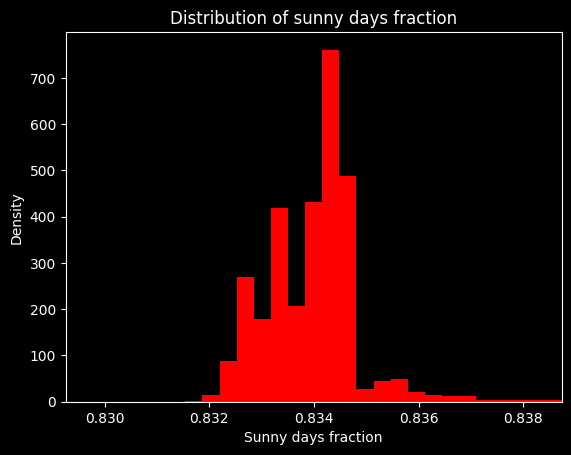

In [3]:
#now we plot an histogram for the plot above
binned1=np.linspace(np.mean(sunny_frac) - 3*np.std(sunny_frac), np.mean(sunny_frac) + 3*np.std(sunny_frac), 30)
plt.hist(sunny_frac, bins=binned1, color='red', label='Sunny days fraction', density=True)
plt.xlabel('Sunny days fraction')
plt.ylabel('Density')
plt.xlim(np.mean(sunny_frac) - 3*np.std(sunny_frac), np.mean(sunny_frac) + 3*np.std(sunny_frac))
plt.title('Distribution of sunny days fraction')
plt.show()

In [4]:
x_scale = np.linspace(np.mean(sunny_frac) - 3*np.std(sunny_frac), np.mean(sunny_frac) + 3*np.std(sunny_frac), 300)

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):    #function stolen from lecture 7
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x_scale[:, np.newaxis]) 
    return np.exp(log_pdf)

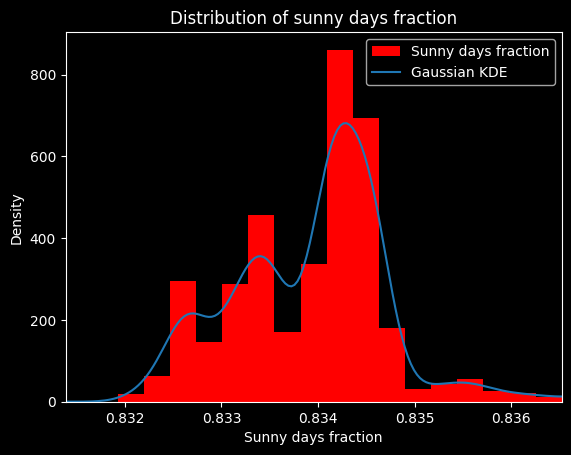

The mean of the sunny days fraction is 0.8339549 with an error 0.0000009


In [21]:
#now we need to use a summary statistics to determine the most likely value and an error on our estimate
#before this we need to discard the burn-in phase where the chain is not in equilibrium (like the first 700 days)
corrected_sunny = np.array(sunny_frac[4000:])
grid_sunny = np.linspace(0.8,0.925,500)

mean_sunny = np.mean(corrected_sunny)
std_sunny = np.std(corrected_sunny)
sigma_mean = std_sunny/np.sqrt(len(corrected_sunny))

analitical_sunny = kde_sklearn(corrected_sunny, bandwidth=2e-4, kernel="gaussian")

binned3=np.linspace(mean_sunny - 3*std_sunny, mean_sunny + 3*std_sunny, 20)

plt.hist(corrected_sunny, bins=binned3, color='red', label='Sunny days fraction', density=True)
plt.plot(x_scale, analitical_sunny, label='Gaussian KDE')
plt.xlabel('Sunny days fraction')
plt.ylabel('Density')
plt.xlim(mean_sunny - 3*std_sunny, mean_sunny + 3*std_sunny)
plt.legend()
plt.title('Distribution of sunny days fraction')
plt.show()
print(f'The mean of the sunny days fraction is {mean_sunny:.7f} with an error {sigma_mean:.7f}')


